In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 1 - Analyse quantitatives des électeurs 


### 1-1 Les jeunes primo-votants

On va analyser les jeunes ou les primo-votants ayant nés entre juin 2006 et mars 2008 

In [44]:
#Ouverture du jeu de données 

jeune = pd.read_csv('jeunes_0608.csv',sep=';',encoding = "ISO-8859-1")
jeune = jeune.rename(columns = {'ï»¿id_bv':'id_bv'})

jeune = jeune.set_index('id_bv',drop='True')

jeune.head(5)

,nombre_jeune,nb_neFrance,nb_neEtranger
id_bv,,,
01_01,17,15,2
01_02,7,7,0
01_03,6,5,1
01_04,13,11,2
01_05,13,13,0


In [45]:
#Quelques caclul

ne_fr = np.sum(jeune["nb_neFrance"])
ne_etr = np.sum(jeune["nb_neEtranger"])

nais = [ne_fr,ne_etr]
names = ["Né en France","Né à l'étranger"]

nais

[17413, 850]

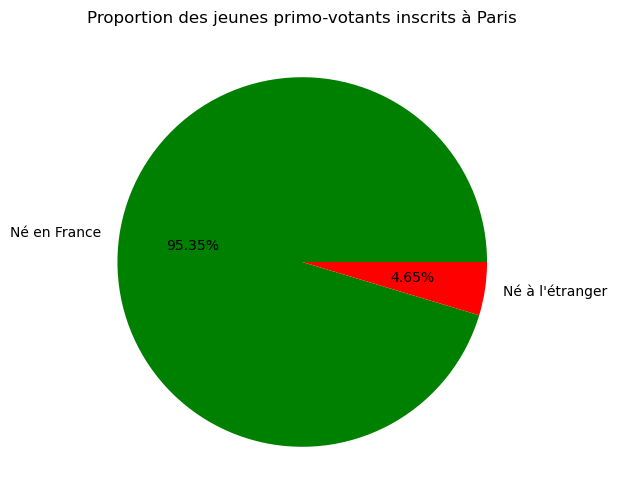

In [46]:
#Diagramme en camemeber

plt.figure(figsize=(10,6))

plt.pie(nais,labels = names, colors = ['green','red'], autopct = '%.2f%%')

plt.title('Proportion des jeunes primo-votants inscrits à Paris')
plt.savefig("jeunes_pie_bv.png")

plt.show()

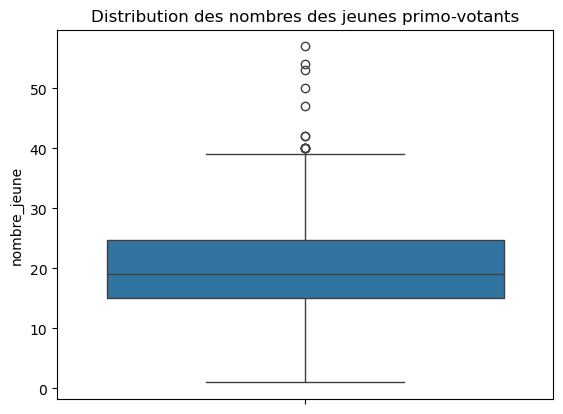

In [47]:
# distribution 


sns.boxplot(jeune["nombre_jeune"])


plt.title("Distribution des nombres des jeunes primo-votants")

plt.savefig("dist_jeune_pv.png")

In [48]:
# Proportion de jeunes par bureau de vote 

leg = pd.read_csv("res_legislatives_24.csv",sep=';',encoding = 'ISO-8859-1')

leg = leg.rename(columns = {"ï»¿id_bv":"id_bv"})

leg = leg.set_index('id_bv',drop='True')


nb_inscrit = pd.DataFrame(leg["nb_inscr"])

nb_inscrit.head(5)

,nb_inscr
id_bv,
01_01,1080
01_02,1211
01_03,1211
01_04,1295
01_05,1077


In [49]:
#Fusionner le nombre de d'inscrit après legislative

jeune = jeune.merge(nb_inscrit,on="id_bv")


# proportion de jeunes par bureau de vote
for i in range(0,len(jeune["nb_inscr"])) :
    jeune["prop"] = round(jeune['nombre_jeune']/jeune["nb_inscr"],3) 

jeune.head(5)

,nombre_jeune,nb_neFrance,nb_neEtranger,nb_inscr,prop
id_bv,,,,,
01_01,17,15,2,1080,0.016
01_02,7,7,0,1211,0.006
01_03,6,5,1,1211,0.005
01_04,13,11,2,1295,0.010
01_05,13,13,0,1077,0.012


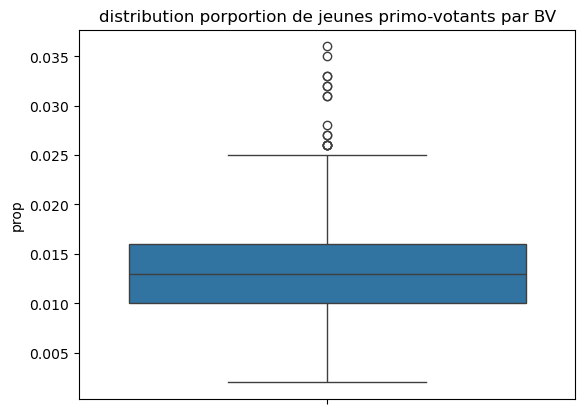

In [50]:
#Distribution des proportions 

sns.boxplot(jeune["prop"])

plt.title("distribution porportion de jeunes primo-votants par BV")

plt.savefig('dist_jeune_prop.png')
plt.show()

On est au alentour de 1,5 % de jeune primo-votant dans la ville de Paris 

### 1-2 - Nombre de personne né à l'étranger 



In [51]:
#Ouverture du fichiers 


etranger= pd.read_csv('etranger_nbr.csv',sep=';',encoding='ISO-8859-1')


etranger = etranger.rename(columns = {'ID Bureau':'id_bv'})
etranger = etranger.set_index('id_bv',drop='True')


etranger.head(5)

,nb_etranger,afr_australe,afr_nord,afr_subs,am_cent,ame_nord,ame_sud,asie_cent,asie_est,asie_sud,asie_sud_est,caraïbes,eur_est,eur_ouest,eur_nord,moyen_orient,oceanie
id_bv,,,,,,,,,,,,,,,,,
01_01,180,5,49,26,0,4,9,0,7,5,9,0,17,43,0,6,0
01_02,206,4,55,16,1,12,7,0,15,6,12,3,10,51,4,8,2
01_03,199,2,55,15,0,11,14,4,5,3,12,2,27,39,0,10,0
01_04,237,4,72,33,0,11,14,1,6,4,14,2,19,47,3,7,0
01_05,168,4,42,17,0,12,12,1,6,2,6,1,18,35,2,9,1


In [52]:
etranger.columns

Index(['nb_etranger', 'afr_australe', 'afr_nord', 'afr_subs', 'am_cent',
       'ame_nord', 'ame_sud', 'asie_cent', 'asie_est', 'asie_sud',
       'asie_sud_est', 'caraïbes', 'eur_est', 'eur_ouest', 'eur_nord',
       'moyen_orient', 'oceanie'],
      dtype='object')

In [53]:
etranger = etranger.merge(nb_inscrit,on="id_bv")

etranger

,nb_etranger,afr_australe,afr_nord,afr_subs,am_cent,ame_nord,ame_sud,asie_cent,asie_est,asie_sud,asie_sud_est,caraïbes,eur_est,eur_ouest,eur_nord,moyen_orient,oceanie,nb_inscr
id_bv,,,,,,,,,,,,,,,,,,
01_01,180,5,49,26,0,4,9,0,7,5,9,0,17,43,0,6,0,1080
01_02,206,4,55,16,1,12,7,0,15,6,12,3,10,51,4,8,2,1211
01_03,199,2,55,15,0,11,14,4,5,3,12,2,27,39,0,10,0,1211
01_04,237,4,72,33,0,11,14,1,6,4,14,2,19,47,3,7,0,1295
01_05,168,4,42,17,0,12,12,1,6,2,6,1,18,35,2,9,1,1077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20_72,358,11,123,90,0,4,17,0,2,9,7,7,28,42,2,13,3,1746
20_73,292,3,77,52,0,10,16,2,5,6,4,1,24,72,5,15,0,1712
20_74,297,7,95,45,1,16,21,1,4,5,14,4,26,42,2,13,1,1760


In [54]:
### Proportion de personnes nés à l'étrangers par bureau de vote 

for i in range(0,len(etranger["nb_etranger"])) :
    etranger["prop"] = round(etranger['nb_etranger']/etranger["nb_inscr"],3) 

etranger.head(5)

,nb_etranger,afr_australe,afr_nord,afr_subs,am_cent,ame_nord,ame_sud,asie_cent,asie_est,asie_sud,asie_sud_est,caraïbes,eur_est,eur_ouest,eur_nord,moyen_orient,oceanie,nb_inscr,prop
id_bv,,,,,,,,,,,,,,,,,,,
01_01,180,5,49,26,0,4,9,0,7,5,9,0,17,43,0,6,0,1080,0.167
01_02,206,4,55,16,1,12,7,0,15,6,12,3,10,51,4,8,2,1211,0.170
01_03,199,2,55,15,0,11,14,4,5,3,12,2,27,39,0,10,0,1211,0.164
01_04,237,4,72,33,0,11,14,1,6,4,14,2,19,47,3,7,0,1295,0.183
01_05,168,4,42,17,0,12,12,1,6,2,6,1,18,35,2,9,1,1077,0.156


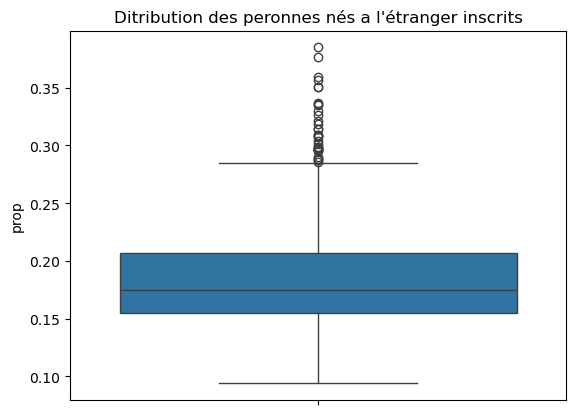

In [55]:
### Distribution du nombre d'étranger 



sns.boxplot(etranger["prop"])

plt.title("Ditribution des peronnes nés a l'étranger inscrits")

plt.show()

### 1-3 - Revenu annuel

In [56]:
#ouverture du jeu de données 

population = pd.read_csv("population.csv",sep=";",encoding="ISO-8859-1")

population = population.set_index('id_bv',drop="True")

population.head(5)

,age_moyen,revenu_annuel
id_bv,,
01_01,49.7,56
01_02,47.6,54
01_03,48.7,36
01_04,49.0,33
01_05,47.0,37


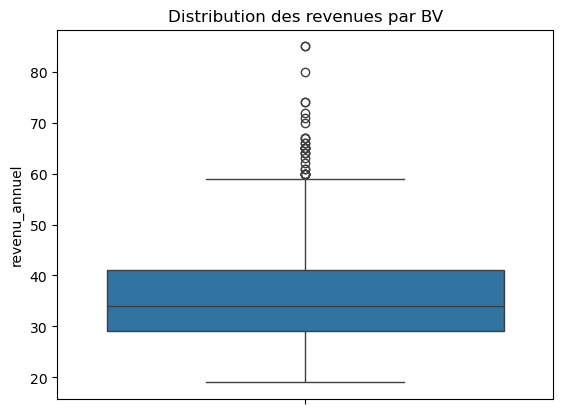

In [57]:
### Distribution du nombre d'étranger 

sns.boxplot(population["revenu_annuel"])

plt.title("Distribution des revenues par BV")

plt.savefig("revenu_BV.png")

plt.show()

### 1-4 Age moyen des élécteurs 

L'âge moyen des élécteurs en 2025 

In [58]:
#joindre les fichiers 


age = pd.DataFrame(population["age_moyen"])

age.head(5)

,age_moyen
id_bv,
01_01,49.7
01_02,47.6
01_03,48.7
01_04,49.0
01_05,47.0


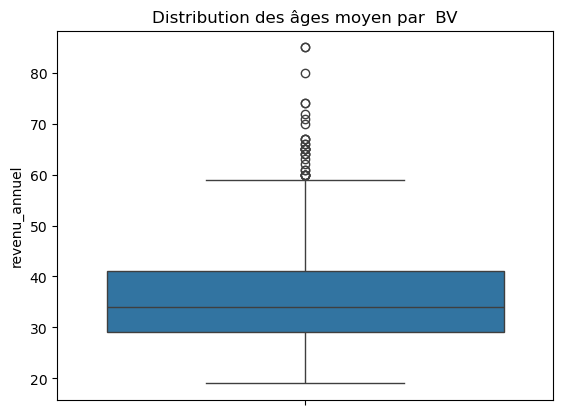

In [59]:
### Distribution du nombre d'étranger 

sns.boxplot(population["revenu_annuel"])

plt.title("Distribution des âges moyen par  BV")

plt.savefig("age_BV.png")

plt.show()

# 2- Analyse quantitatives des caractéristiques des bureux de votes 

### 2-1 Prix moyen par mètre carré 

In [60]:
#Ouverture des fichiers "logement"

logement = pd.read_csv("logement.csv",sep=';',encoding="ISO-8859-1")

logement = logement.rename(columns = {"ID Bureau":"id_bv"})

logement = logement.set_index("id_bv",drop='True')

logement.head(5)

,habitat_principal,statut_logSocial,pour_logSocial,pourct_T1/T2,prix_immo_m2
id_bv,,,,,
01_01,ancien_standing,déficit,0.01,0.20,12.7
01_02,ancien_non_conforme,déficit,0.05,0.65,13.0
01_03,ancien_conforme,déficit,0.05,0.80,10.0
01_04,ancien_conforme,déficit,0.05,0.80,10.3
01_05,ancien_conforme,conforme,0.30,0.80,9.5


In [61]:
prix_immo = logement["prix_immo_m2"]

prix_immo

id_bv
01_01    12.7
01_02    13.0
01_03    10.0
01_04    10.3
01_05     9.5
         ... 
20_72     5.1
20_73     5.6
20_74     5.0
20_75     4.2
20_76     3.9
Name: prix_immo_m2, Length: 902, dtype: float64

<Axes: ylabel='prix_immo_m2'>

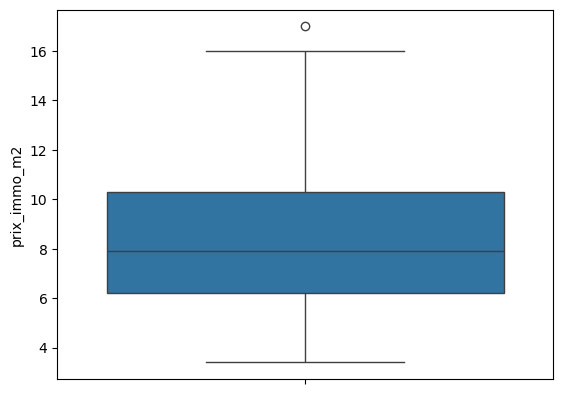

In [62]:
sns.boxplot(prix_immo)

In [63]:
#prix immobilier moyen 

round(np.mean(prix_immo),5) * 1000

8441.46

Le prix moyen d'un logmenet à Paris est de 8 441 €  au mètre carrée

### 2-2 Pourcentage de logement sociaux par BV



In [64]:
p_logSo  = logement["pour_logSocial"]

<Axes: ylabel='pour_logSocial'>

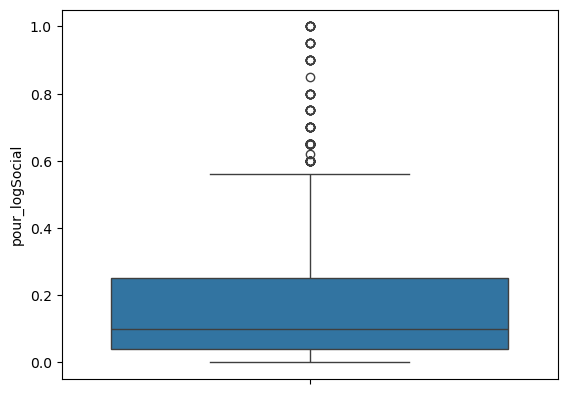

In [65]:
sns.boxplot(p_logSo)

On remarque qu'il y a 75% des bureau de votes ont un taux de logment social inférieur à 25% des habitations

In [66]:
np.mean(p_logSo)

0.1966186252771618

### 2-3 Nombre de pièces 

On cherche le taux de logement de type T1 ou T2 par bureau de vote

In [67]:
piece = logement["pourct_T1/T2"]

piece

id_bv
01_01    0.20
01_02    0.65
01_03    0.80
01_04    0.80
01_05    0.80
         ... 
20_72    0.55
20_73    0.65
20_74    0.70
20_75    0.67
20_76    0.80
Name: pourct_T1/T2, Length: 902, dtype: float64

<Axes: ylabel='pourct_T1/T2'>

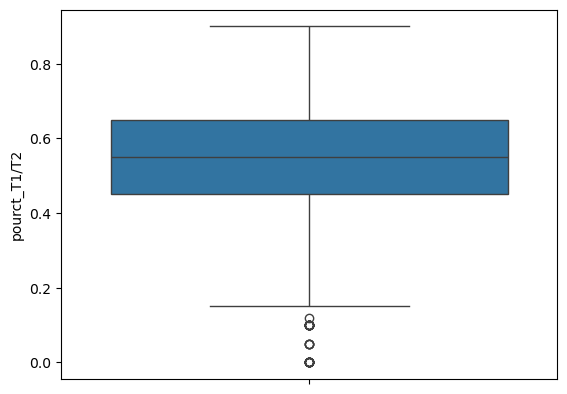

In [68]:
sns.boxplot(piece)

In [69]:
np.mean(piece)

0.5290576496674058

Il y a comment une bonne partie de logement sont de type T1 ou T2 

# 3 - Anlayse bi-variés  : Variables quantitatives

Le but est de faire une analyse entre 2 variables quantitatives 

Pour cela on utilisera un test de corrélation entre ces varibles quantitaives , on va les mettres tous dans un même jeux de données avec les données électoraux (droite gauche + résultats par partie aux éuropéennes 2024)

In [70]:
#Construction d'un jeux de données 

etranger_prop = pd.DataFrame(etranger["prop"])

jeune = pd.DataFrame(jeune)


#Fusionner des données

quant = jeune.merge(etranger_prop,on='id_bv')
quant = quant.rename(columns = {'prop_x':'p_jeune','prop_y':'p_etranger'})
quant = quant.merge(population,on = 'id_bv')


# Fusion avec les donneés de logment 

prix_immo = pd.DataFrame(prix_immo)
quant = quant.merge(prix_immo,on='id_bv')

piece = pd.DataFrame(piece)
quant = quant.merge(piece,on='id_bv')

logSo = pd.DataFrame(p_logSo)
quant = quant.merge(logSo,on='id_bv')


quant

,nombre_jeune,nb_neFrance,nb_neEtranger,nb_inscr,p_jeune,p_etranger,age_moyen,revenu_annuel,prix_immo_m2,pourct_T1/T2,pour_logSocial
id_bv,,,,,,,,,,,
01_01,17,15,2,1080,0.016,0.167,49.7,56,12.7,0.20,0.01
01_02,7,7,0,1211,0.006,0.170,47.6,54,13.0,0.65,0.05
01_03,6,5,1,1211,0.005,0.164,48.7,36,10.0,0.80,0.05
01_04,13,11,2,1295,0.010,0.183,49.0,33,10.3,0.80,0.05
01_05,13,13,0,1077,0.012,0.156,47.0,37,9.5,0.80,0.30
...,...,...,...,...,...,...,...,...,...,...,...
20_72,22,22,0,1746,0.013,0.205,46.4,26,5.1,0.55,0.55
20_73,26,26,0,1712,0.015,0.171,46.2,27,5.6,0.65,0.15
20_74,13,12,1,1760,0.007,0.169,47.2,26,5.0,0.70,0.30


Avec les données obtenus , on va faire un 1er test de corrélation (test de Pearson).




In [71]:


quant2 = quant.reset_index()

quant2 = quant2.drop(['id_bv','nb_neFrance','nb_neEtranger'],axis=1)




quant_corr = quant2.corr()

In [72]:
quant_corr

,nombre_jeune,nb_inscr,p_jeune,p_etranger,age_moyen,revenu_annuel,prix_immo_m2,pourct_T1/T2,pour_logSocial
nombre_jeune,1.000000,0.286220,0.924420,0.451091,-0.135023,-0.051662,-0.166488,-0.275329,0.345655
nb_inscr,0.286220,1.000000,-0.067619,0.046221,-0.341657,-0.309985,-0.322398,0.205936,0.069574
p_jeune,0.924420,-0.067619,1.000000,0.453204,-0.033972,0.043287,-0.076172,-0.361838,0.341664
p_etranger,0.451091,0.046221,0.453204,1.000000,-0.010836,-0.320219,-0.322027,-0.259243,0.624921
age_moyen,-0.135023,-0.341657,-0.033972,-0.010836,1.000000,0.415954,0.412632,-0.283143,-0.076623
revenu_annuel,-0.051662,-0.309985,0.043287,-0.320219,0.415954,1.000000,0.758431,-0.282080,-0.516260
prix_immo_m2,-0.166488,-0.322398,-0.076172,-0.322027,0.412632,0.758431,1.000000,-0.116171,-0.511799
pourct_T1/T2,-0.275329,0.205936,-0.361838,-0.259243,-0.283143,-0.282080,-0.116171,1.000000,-0.231983
pour_logSocial,0.345655,0.069574,0.341664,0.624921,-0.076623,-0.516260,-0.511799,-0.231983,1.000000


Text(0.5, 1.0, 'Matrice de corrélation 1')

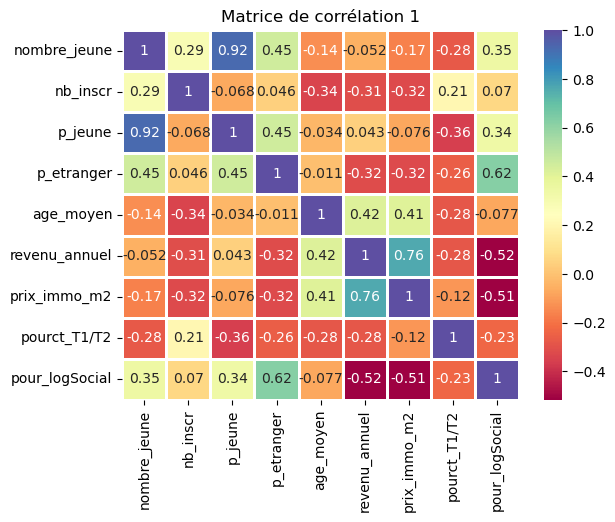

In [73]:
sns.heatmap(quant_corr,cmap="Spectral",annot=True,linewidth=0.9)

plt.title("Matrice de corrélation 1")

On remarque qu'il y a certaines corréaltion 

On va faire un 2e test de corrélation avec les données électorale 

#### Corrélation avec les donnée électorale de gauche 

In [74]:
# Donnée électorale de gauche 


gauche = pd.read_csv('res_gauche.csv',sep=";",encoding="ISO-8859-1")

gauche = gauche.rename(columns={"ï»¿id_bv":"id_bv"})

gauche = gauche.set_index('id_bv',drop='True')


gauche2 = gauche.reset_index()

gauche2 = gauche2.drop(['total_G_EUR','total_G_LEG','partie_dominant'],axis=1)

gauche2.head(5)

,id_bv,ecart_voix_G,p_G_EUR,p_G_LEG,nb_PS,nb_EELV,nb_PCF,nb_LFI,autresGauche,ExtGauche
0,01_01,-13,0.4617,0.3648,136,66,4,84,3,2
1,01_02,-17,0.4796,0.3486,171,72,5,71,9,1
2,01_03,-46,0.4933,0.3730,178,86,11,86,5,3
3,01_04,44,0.5328,0.4822,175,66,15,125,5,4
4,01_05,-17,0.5248,0.3924,173,79,5,75,5,1


In [75]:
#Fussionner avec la 1er matrice de corrélation 

gauche2 = gauche2.set_index('id_bv',drop="True")

quant_gauche = quant.merge(gauche2,on='id_bv')

quant_gauche.head(5)

,nombre_jeune,nb_neFrance,nb_neEtranger,nb_inscr,p_jeune,p_etranger,age_moyen,revenu_annuel,prix_immo_m2,pourct_T1/T2,pour_logSocial,ecart_voix_G,p_G_EUR,p_G_LEG,nb_PS,nb_EELV,nb_PCF,nb_LFI,autresGauche,ExtGauche
id_bv,,,,,,,,,,,,,,,,,,,,
01_01,17,15,2,1080,0.016,0.167,49.7,56,12.7,0.20,0.01,-13,0.4617,0.3648,136,66,4,84,3,2
01_02,7,7,0,1211,0.006,0.170,47.6,54,13.0,0.65,0.05,-17,0.4796,0.3486,171,72,5,71,9,1
01_03,6,5,1,1211,0.005,0.164,48.7,36,10.0,0.80,0.05,-46,0.4933,0.3730,178,86,11,86,5,3
01_04,13,11,2,1295,0.010,0.183,49.0,33,10.3,0.80,0.05,44,0.5328,0.4822,175,66,15,125,5,4
01_05,13,13,0,1077,0.012,0.156,47.0,37,9.5,0.80,0.30,-17,0.5248,0.3924,173,79,5,75,5,1


In [76]:
quant_gauche = quant_gauche.reset_index()



In [77]:
quant_gauche = quant_gauche.drop('id_bv',axis=1)

quant_gauche

,nombre_jeune,nb_neFrance,nb_neEtranger,nb_inscr,p_jeune,p_etranger,age_moyen,revenu_annuel,prix_immo_m2,pourct_T1/T2,pour_logSocial,ecart_voix_G,p_G_EUR,p_G_LEG,nb_PS,nb_EELV,nb_PCF,nb_LFI,autresGauche,ExtGauche
0,17,15,2,1080,0.016,0.167,49.7,56,12.7,0.20,0.01,-13,0.4617,0.3648,136,66,4,84,3,2
1,7,7,0,1211,0.006,0.170,47.6,54,13.0,0.65,0.05,-17,0.4796,0.3486,171,72,5,71,9,1
2,6,5,1,1211,0.005,0.164,48.7,36,10.0,0.80,0.05,-46,0.4933,0.3730,178,86,11,86,5,3
3,13,11,2,1295,0.010,0.183,49.0,33,10.3,0.80,0.05,44,0.5328,0.4822,175,66,15,125,5,4
4,13,13,0,1077,0.012,0.156,47.0,37,9.5,0.80,0.30,-17,0.5248,0.3924,173,79,5,75,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
896,22,22,0,1746,0.013,0.205,46.4,26,5.1,0.55,0.55,171,0.7712,0.7577,196,133,21,378,7,10
897,26,26,0,1712,0.015,0.171,46.2,27,5.6,0.65,0.15,76,0.7910,0.7254,307,195,18,323,5,11
898,13,12,1,1760,0.007,0.169,47.2,26,5.0,0.70,0.30,77,0.8092,0.7523,317,197,28,364,7,3
899,20,20,0,1864,0.011,0.254,45.4,25,4.2,0.67,0.25,212,0.7804,0.7636,142,117,21,386,7,13


In [78]:
quant_corr_G = quant_gauche.corr()

quant_corr_G

,nombre_jeune,nb_neFrance,nb_neEtranger,nb_inscr,p_jeune,p_etranger,age_moyen,revenu_annuel,prix_immo_m2,pourct_T1/T2,pour_logSocial,ecart_voix_G,p_G_EUR,p_G_LEG,nb_PS,nb_EELV,nb_PCF,nb_LFI,autresGauche,ExtGauche
nombre_jeune,1.000000,0.990368,0.357133,0.286220,0.924420,0.451091,-0.135023,-0.051662,-0.166488,-0.275329,0.345655,0.327909,-0.024205,0.061324,-0.289547,-0.217616,0.023547,0.269234,-0.044979,0.104209
nb_neFrance,0.990368,1.000000,0.224363,0.292574,0.911758,0.446302,-0.147363,-0.074910,-0.192624,-0.266151,0.355195,0.340533,0.001013,0.085466,-0.273582,-0.199455,0.040070,0.288679,-0.028916,0.121345
nb_neEtranger,0.357133,0.224363,1.000000,0.040756,0.355488,0.164091,0.043796,0.141739,0.127672,-0.142353,0.036627,0.010638,-0.177189,-0.144942,-0.192295,-0.186088,-0.104581,-0.052515,-0.121504,-0.085152
nb_inscr,0.286220,0.292574,0.040756,1.000000,-0.067619,0.046221,-0.341657,-0.309985,-0.322398,0.205936,0.069574,0.241285,0.311191,0.293275,0.433649,0.498588,0.389474,0.522985,0.325635,0.307235
p_jeune,0.924420,0.911758,0.355488,-0.067619,1.000000,0.453204,-0.033972,0.043287,-0.076172,-0.361838,0.341664,0.258763,-0.120339,-0.024837,-0.446268,-0.390583,-0.103791,0.098975,-0.157902,0.008395
p_etranger,0.451091,0.446302,0.164091,0.046221,0.453204,1.000000,-0.010836,-0.320219,-0.322027,-0.259243,0.624921,0.640887,0.120003,0.256402,-0.558220,-0.410960,0.052250,0.413930,-0.132305,0.208679
age_moyen,-0.135023,-0.147363,0.043796,-0.341657,-0.033972,-0.010836,1.000000,0.415954,0.412632,-0.283143,-0.076623,-0.341795,-0.518139,-0.479155,-0.277248,-0.455138,-0.207651,-0.503762,-0.168364,-0.247855
revenu_annuel,-0.051662,-0.074910,0.141739,-0.309985,0.043287,-0.320219,0.415954,1.000000,0.758431,-0.282080,-0.516260,-0.667749,-0.783764,-0.807978,-0.291956,-0.417063,-0.549366,-0.743340,-0.257247,-0.505368
prix_immo_m2,-0.166488,-0.192624,0.127672,-0.322398,-0.076172,-0.322027,0.412632,0.758431,1.000000,-0.116171,-0.511799,-0.651113,-0.725634,-0.761529,-0.210342,-0.379396,-0.527477,-0.750082,-0.253196,-0.506063
pourct_T1/T2,-0.275329,-0.266151,-0.142353,0.205936,-0.361838,-0.259243,-0.283143,-0.282080,-0.116171,1.000000,-0.231983,-0.017986,0.297619,0.221713,0.417972,0.431365,0.175934,0.169109,0.163219,0.128991


Text(0.5, 1.0, 'Matrice de corrélation de Gauche')

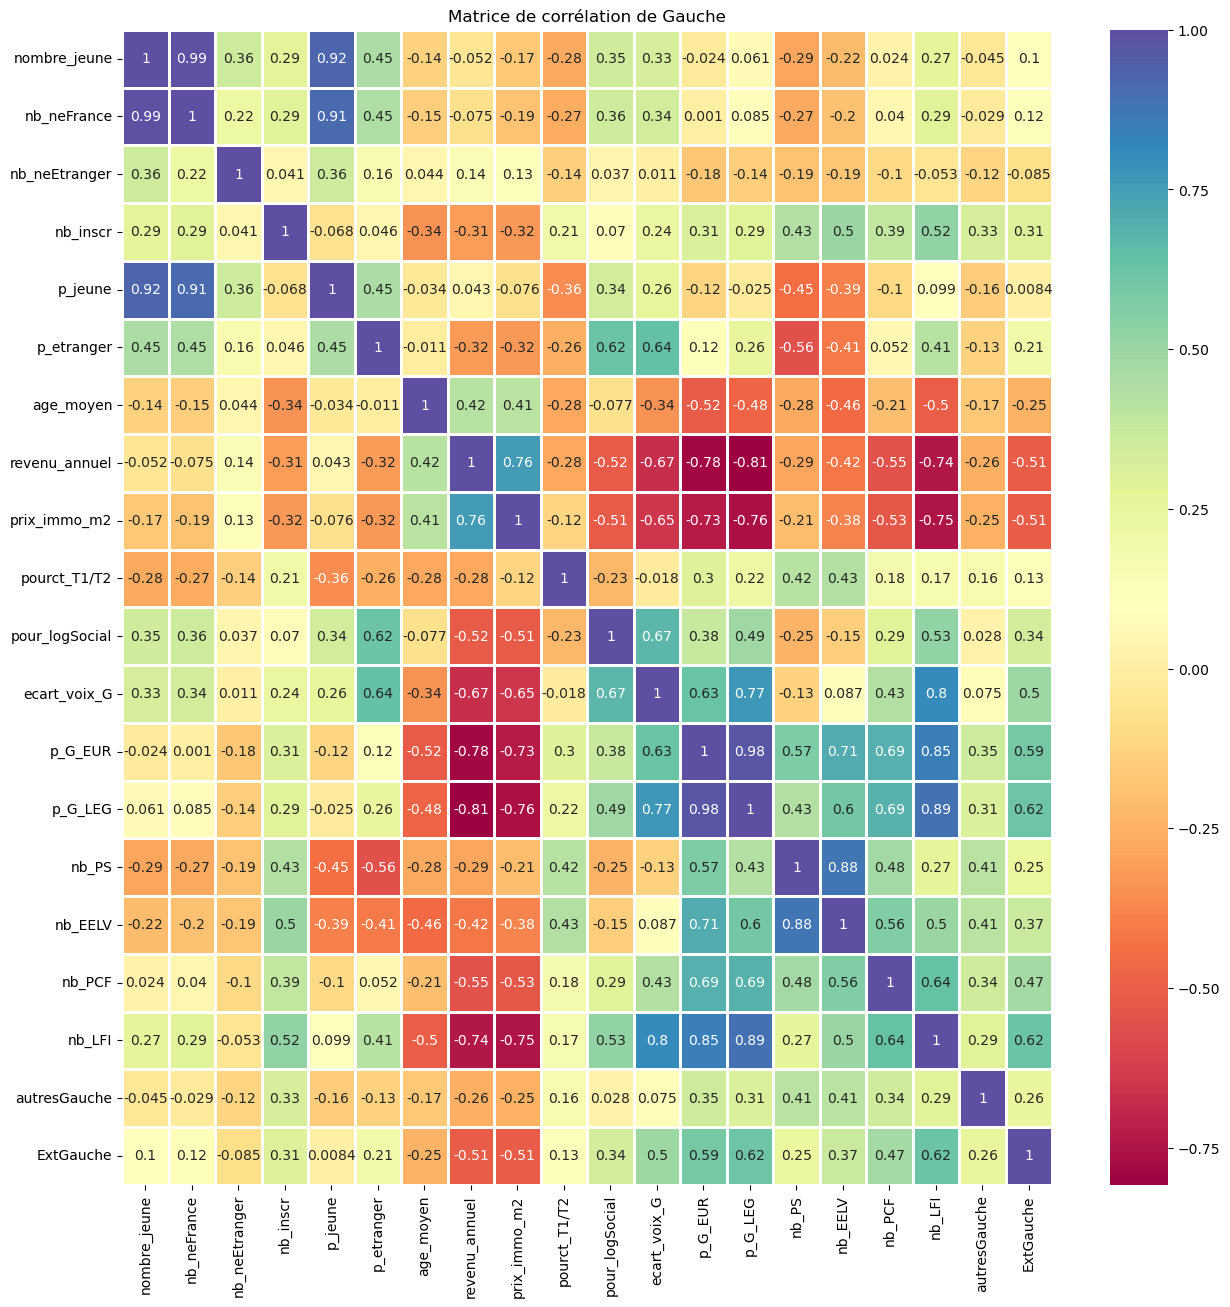

In [79]:

plt.figure(figsize=(15,15))

sns.heatmap(quant_corr_G,cmap="Spectral",annot=True,linewidth=0.9)

plt.title("Matrice de corrélation de Gauche")

#### Corrélation avec les donnée électorale de droite

In [80]:
#Ouverture du jeu de données de droite 

droite = pd.read_csv("res_droite.csv",sep=";",encoding="ISO-8859-1")
droite = droite.rename(columns = {"ï»¿id_bv":"id_bv"})
droite = droite.set_index('id_bv')


#Suprression des colonnes inutiles 

droite2 = droite.reset_index()
droite2 = droite2.drop(['v_D_EUR','v_D_LEG','partie_dominant'],axis=1)
droite2.head(5)



#Fussionner avec la 1er matrice de corrélation 

droite2 = droite2.set_index('id_bv',drop="True")
quant_droite = quant.merge(droite2,on='id_bv')
quant_droite.head(5)

,nombre_jeune,nb_neFrance,nb_neEtranger,nb_inscr,p_jeune,p_etranger,age_moyen,revenu_annuel,prix_immo_m2,pourct_T1/T2,pour_logSocial,p_D_EUR,p_D_LEG,ecart_D,nb_LR,nb_RN,nb_Rec,nb_autreDroite,nb_extDroite
id_bv,,,,,,,,,,,,,,,,,,,
01_01,17,15,2,1080,0.016,0.167,49.7,56,12.7,0.20,0.01,0.2942,0.2147,-22,72,60,42,2,12
01_02,7,7,0,1211,0.006,0.170,47.6,54,13.0,0.65,0.05,0.2245,0.1832,10,54,54,37,2,7
01_03,6,5,1,1211,0.005,0.164,48.7,36,10.0,0.80,0.05,0.2447,0.2252,12,58,71,37,0,17
01_04,13,11,2,1295,0.010,0.183,49.0,33,10.3,0.80,0.05,0.2391,0.1678,-24,51,69,34,1,20
01_05,13,13,0,1077,0.012,0.156,47.0,37,9.5,0.80,0.30,0.2376,0.1687,-15,44,53,41,3,12


In [81]:

quant_droite = quant_droite.reset_index()

quant_droite = quant_droite.drop("id_bv",axis=1)


#Matrice de corrélation

quant_corr_D = quant_droite.corr()

quant_corr_D


,nombre_jeune,nb_neFrance,nb_neEtranger,nb_inscr,p_jeune,p_etranger,age_moyen,revenu_annuel,prix_immo_m2,pourct_T1/T2,pour_logSocial,p_D_EUR,p_D_LEG,ecart_D,nb_LR,nb_RN,nb_Rec,nb_autreDroite,nb_extDroite
nombre_jeune,1.000000,0.990368,0.357133,0.286220,0.924420,0.451091,-0.135023,-0.051662,-0.166488,-0.275329,0.345655,0.156758,0.197006,0.172847,0.071253,0.331582,0.163928,0.055243,0.167713
nb_neFrance,0.990368,1.000000,0.224363,0.292574,0.911758,0.446302,-0.147363,-0.074910,-0.192624,-0.266151,0.355195,0.133114,0.176790,0.186131,0.046660,0.322211,0.141597,0.056298,0.170674
nb_neEtranger,0.357133,0.224363,1.000000,0.040756,0.355488,0.164091,0.043796,0.141739,0.127672,-0.142353,0.036627,0.205295,0.193931,-0.039119,0.186717,0.160090,0.198537,0.009020,0.029022
nb_inscr,0.286220,0.292574,0.040756,1.000000,-0.067619,0.046221,-0.341657,-0.309985,-0.322398,0.205936,0.069574,-0.268423,-0.205856,0.148984,-0.069349,0.173906,-0.015096,0.154457,0.254129
p_jeune,0.924420,0.911758,0.355488,-0.067619,1.000000,0.453204,-0.033972,0.043287,-0.076172,-0.361838,0.341664,0.243517,0.263845,0.129612,0.085447,0.267873,0.161213,0.006214,0.075132
p_etranger,0.451091,0.446302,0.164091,0.046221,0.453204,1.000000,-0.010836,-0.320219,-0.322027,-0.259243,0.624921,0.066902,0.108168,0.349271,-0.263949,0.275710,-0.106154,-0.007887,0.225719
age_moyen,-0.135023,-0.147363,0.043796,-0.341657,-0.033972,-0.010836,1.000000,0.415954,0.412632,-0.283143,-0.076623,0.499895,0.460453,-0.219274,0.398456,0.377276,0.367857,0.058471,0.081916
revenu_annuel,-0.051662,-0.074910,0.141739,-0.309985,0.043287,-0.320219,0.415954,1.000000,0.758431,-0.282080,-0.516260,0.700037,0.607930,-0.426615,0.766124,0.183054,0.696616,-0.112410,-0.186256
prix_immo_m2,-0.166488,-0.192624,0.127672,-0.322398,-0.076172,-0.322027,0.412632,0.758431,1.000000,-0.116171,-0.511799,0.604412,0.513549,-0.398969,0.666962,0.116895,0.583652,-0.112193,-0.156841
pourct_T1/T2,-0.275329,-0.266151,-0.142353,0.205936,-0.361838,-0.259243,-0.283143,-0.282080,-0.116171,1.000000,-0.231983,-0.373721,-0.367398,-0.011117,-0.231368,-0.267991,-0.265367,0.027655,-0.024609


Text(0.5, 1.0, 'Matrice de corrélation de Droite')

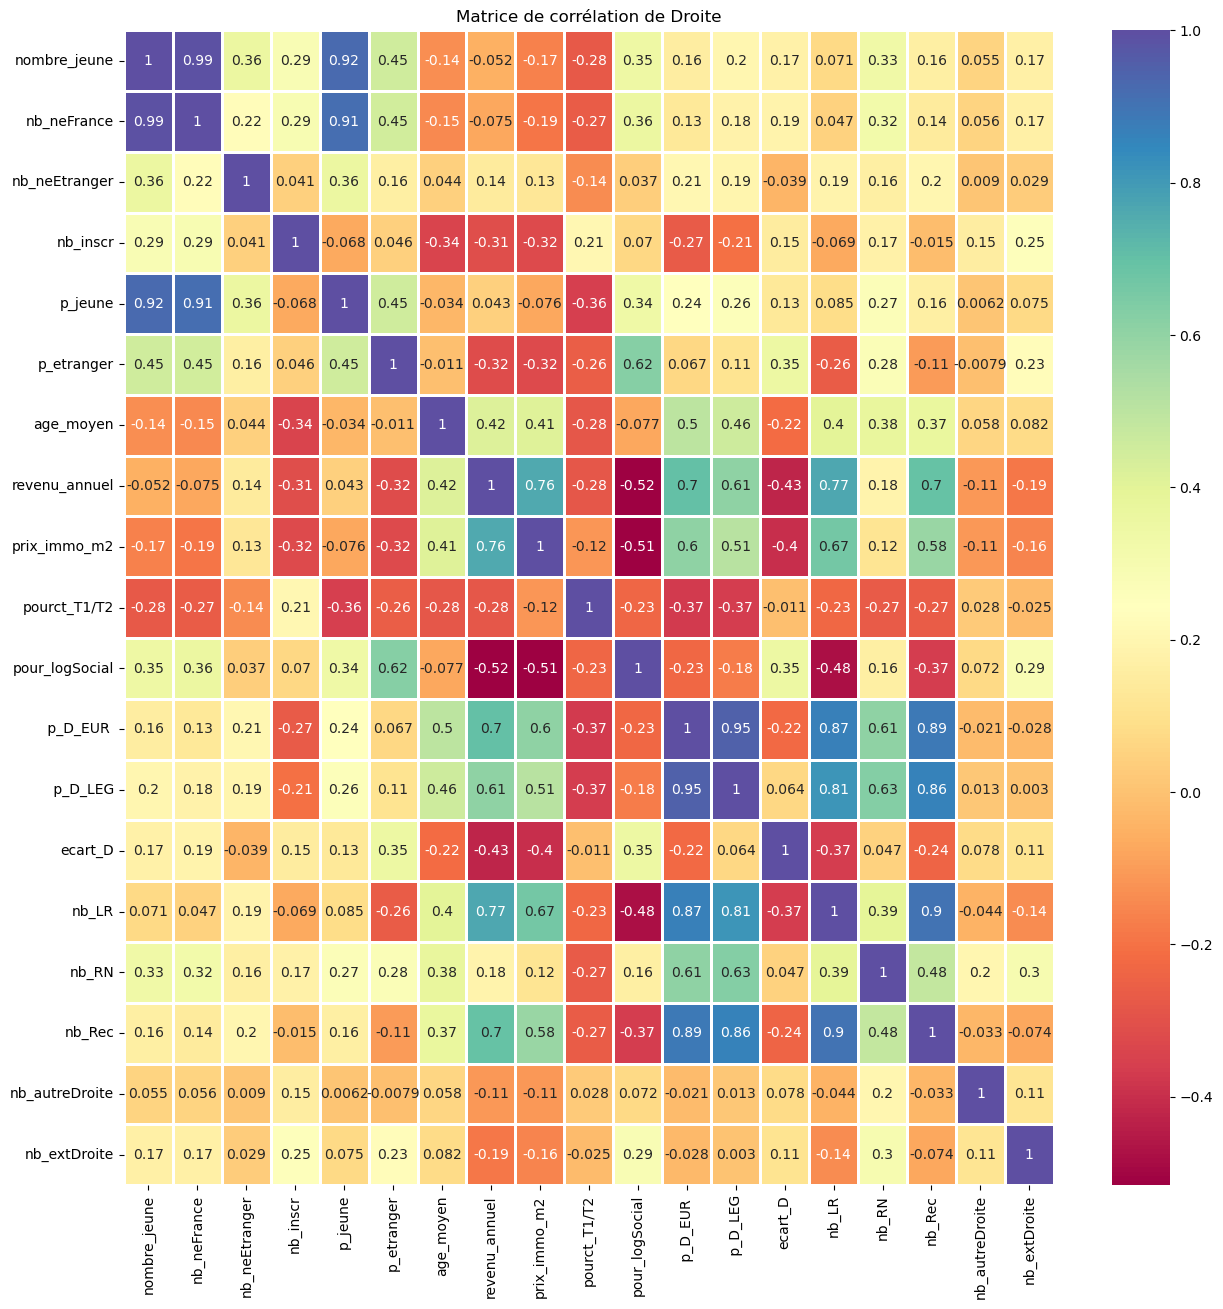

In [82]:
plt.figure(figsize=(15,15))

sns.heatmap(quant_corr_D,cmap="Spectral",annot=True,linewidth=0.9)

plt.title("Matrice de corrélation de Droite")

# 4  - Test de comparaison 



In [93]:
#Ouverture des données de gauche


#Prendre la partie partie de gauche 
partie_gauche = pd.DataFrame(gauche['partie_dominant'])

partie_gauche = partie_gauche.rename(columns={"partie_dominant":"partie_gauche"})


partie_gauche.head(5)

,partie_gauche
id_bv,
01_01,Partie Socialiste
01_02,Partie Socialiste
01_03,Partie Socialiste
01_04,Partie Socialiste
01_05,Partie Socialiste


In [94]:
#Partie de droite

partie_droite = pd.DataFrame(droite["partie_dominant"])

partie_droite = partie_droite.rename(columns={"partie_dominant":"partie_droite"})

partie_droite.head(5)

,partie_droite
id_bv,
01_01,Les RÃ©publicains
01_02,Les RÃ©publicains
01_03,Rassemblement National
01_04,Rassemblement National
01_05,Rassemblement National


In [97]:
#Fusionner avec les données des parties 

quant_partie = quant.merge(partie_gauche,on='id_bv')

quant_partie = quant_partie.merge(partie_droite,on='id_bv')

quant_partie.head(5)

,nombre_jeune,nb_neFrance,nb_neEtranger,nb_inscr,p_jeune,p_etranger,age_moyen,revenu_annuel,prix_immo_m2,pourct_T1/T2,pour_logSocial,partie_gauche,partie_droite
id_bv,,,,,,,,,,,,,
01_01,17,15,2,1080,0.016,0.167,49.7,56,12.7,0.20,0.01,Partie Socialiste,Les RÃ©publicains
01_02,7,7,0,1211,0.006,0.170,47.6,54,13.0,0.65,0.05,Partie Socialiste,Les RÃ©publicains
01_03,6,5,1,1211,0.005,0.164,48.7,36,10.0,0.80,0.05,Partie Socialiste,Rassemblement National
01_04,13,11,2,1295,0.010,0.183,49.0,33,10.3,0.80,0.05,Partie Socialiste,Rassemblement National
01_05,13,13,0,1077,0.012,0.156,47.0,37,9.5,0.80,0.30,Partie Socialiste,Rassemblement National


In [98]:
count_droite = quant_partie["partie_droite"].value_counts()

count_droite

partie_droite
Les RÃ©publicains         482
Rassemblement National    416
ReconquÃªte                 3
Name: count, dtype: int64

In [99]:
count_gauche = quant_partie["partie_gauche"].value_counts()

count_gauche

partie_gauche
Partie Socialiste      701
La France Insoumise    200
Name: count, dtype: int64

In [100]:
#Ouverture du module pour le test de tudent 

import scipy.stats as stats

### 4-1 Test sur le revenue 

In [117]:
# Ouverture du jeu de données 

ps = quant_partie[quant_partie["partie_gauche"] == "Partie Socialiste"]

ps_revenue = ps["revenu_annuel"]


lfi = quant_partie[quant_partie["partie_gauche"] == "La France Insoumise"]

lfi_revenue = lfi["revenu_annuel"]



lr = quant_partie[quant_partie["partie_droite"] == "Les RÃ©publicains"]

lr_revenue = lr["revenu_annuel"]


rn = quant_partie[quant_partie["partie_droite"] == "Rassemblement National"]

rn_revenue = rn["revenu_annuel"]

In [118]:
[np.mean(ps_revenue),np.mean(lfi_revenue)]

[38.71754636233951, 27.27]

In [119]:
rev_G = stats.ttest_ind(ps_revenue,lfi_revenue) 

print(rev_G)

TtestResult(statistic=16.07986135724875, pvalue=2.515445802755137e-51, df=899.0)


In [120]:
[np.mean(lr_revenue),np.mean(rn_revenue)]

[41.821576763485474, 29.685096153846153]

In [122]:
rev_D = stats.ttest_ind(lr_revenue,rn_revenue) 

print(rev_D)

TtestResult(statistic=22.505591099072333, pvalue=2.9325886777346476e-89, df=896.0)


### 4-2 Jeune % 




In [123]:
# Ouverture du jeu de données 

ps_jeune = ps["p_jeune"]

lfi_jeune = lfi["p_jeune"]

lr_jeune = lr["p_jeune"]

rn_jeune = rn["p_jeune"]

In [124]:
[np.mean(ps_jeune),np.mean(lfi_jeune)]

[0.012338088445078457, 0.017105000000000002]

In [125]:
j_G = stats.ttest_ind(ps_jeune,lfi_jeune) 

print(j_G)

TtestResult(statistic=-13.128191492470265, pvalue=3.803270078302548e-36, df=899.0)


In [126]:
[np.mean(lr_jeune),np.mean(rn_jeune)]

[0.012713692946058092, 0.01418269230769231]

In [128]:
j_D = stats.ttest_ind(rn_jeune,lr_jeune) 

print(j_D)

TtestResult(statistic=4.48295269677769, pvalue=8.316325241532453e-06, df=896.0)


### 4-3 Etranger %

On va tester pour les personnes né à l'étranger 

In [129]:
# Ouverture du jeu de données 

ps_etranger = ps["p_etranger"]

lfi_etranger = lfi["p_etranger"]

lr_etranger = lr["p_etranger"]

rn_etranger = rn["p_etranger"]

In [130]:
[np.mean(ps_etranger),np.mean(lfi_etranger)]

[0.16948074179743222, 0.24414000000000002]

In [131]:
e_G = stats.ttest_ind(ps_etranger,lfi_etranger) 

print(e_G)

TtestResult(statistic=-28.44811760100772, pvalue=1.8389076744919487e-127, df=899.0)


In [132]:
[np.mean(lr_etranger),np.mean(rn_etranger)]

[0.16907883817427385, 0.20549038461538463]

In [133]:
e_G = stats.ttest_ind(lr_etranger,rn_etranger) 

print(e_G)

TtestResult(statistic=-13.177550305964628, pvalue=2.24953642590176e-36, df=896.0)


### 4-4 Taux de logement sociaux 

on va tester sur le pourcentage de logment sociaux

In [134]:
# Ouverture du jeu de données 

ps_social = ps["pour_logSocial"]

lfi_social = lfi["pour_logSocial"]

lr_social = lr["pour_logSocial"]

rn_social = rn["pour_logSocial"]

In [135]:
[np.mean(ps_social),np.mean(lfi_social)]

[0.11971469329529247, 0.4669]

In [136]:
l_G = stats.ttest_ind(ps_social,lfi_social) 

print(l_G)

TtestResult(statistic=-23.601793095385155, pvalue=3.167860020421953e-96, df=899.0)


In [138]:
[np.mean(lr_social),np.mean(rn_social)]

[0.07894190871369294, 0.3326923076923076]

In [137]:
l_D = stats.ttest_ind(lr_social,rn_social) 

print(l_D)

TtestResult(statistic=-19.333209624000826, pvalue=7.15770751083602e-70, df=896.0)


On a pu voir après ces tests de comparaison que les deux parties de gauches se distinguent du même pour les partis de droites . On constate que les partie de la France Insoumise va dans la même direction que le partie de droite du Rassemblement Nationale : donc on pourrait faire un test entre parti politique avec l'aide de test de Khi-2 (test d'entre catégories)

# 5 - Test catégoriques - Khi-2

On pourrait faire un test de KHI-2 entre les partie de gauches ou les parties de droites 

Le but de ce est de voir si on a des liaisons entre les parties de gauche et celle de droites 

In [140]:
#Test statistiques entre partie politiques

pol_tab = pd.crosstab(quant_partie['partie_gauche'],quant_partie['partie_droite'])

pol_tab

partie_droite,Les RÃ©publicains,Rassemblement National,ReconquÃªte
partie_gauche,,,
La France Insoumise,8,191,1
Partie Socialiste,474,225,2


In [141]:
from scipy.stats import chi2_contingency as chi2_contingency

khi2, pval , ddl , contingent_theorique = chi2_contingency(pol_tab)

In [142]:
# statistiques de Khi-2
khi2

253.41687488671417

In [143]:
# la p-valeur

pval

9.358900019594456e-56

In [144]:
#degré de liberté 

ddl

2

In [147]:
#Résulats théoriques

pol_theorique = pd.DataFrame(contingent_theorique)


pol_theorique = pol_theorique.rename(columns = {0:"Les Républicains",1:"Rassemblement National",2:"Reconquête"},
                                     index = {0:"La France Insoumise",1:"Partie Socialiste"})

pol_theorique

,Les Républicains,Rassemblement National,Reconquête
La France Insoumise,106.992231,92.341842,0.665927
Partie Socialiste,375.007769,323.658158,2.334073


D'après les test de KHI-2, on ne peut pas dire que les parties de gauche et de droites sont indépendantes 

#### Mesure de Crémer 

In [150]:
# n = total des effectifs observés
n = pol_tab.sum().sum()  

# paramètres
chi2 = 253.41687488671417
r, c = pol_tab.shape
v_cramer = np.sqrt(chi2 / (n * (min(r-1, c-1))))

print("V de Cramér =", v_cramer)

V de Cramér = 0.5303412036859825


On a la mesure de Cramér est très élevé donc il y a une liaison évident entre ces deux variables 